In [1]:
import numpy as np
import pymc as pm

In [2]:
sample_proportions = np.array([
    [0.65, 0.3, 0.05, 0., 0.],
    [0.7, 0.2, 0.1, 0., 0.],
    [0.3, 0.7, 0., 0., 0.],
    [0.4, 0.5, 0.1, 0., 0.],
])

In [3]:
K = sample_proportions.shape[1]

# Dirichlet requires strictly positive entries; clamp zeros and renormalize
eps = 1e-6
props = np.clip(sample_proportions, eps, None)
props = props / props.sum(axis=1, keepdims=True)

with pm.Model() as dirichlet_model:
    alpha = pm.Gamma("alpha", alpha=5, beta=5, shape=K)
    obs = pm.Dirichlet("obs", a=alpha, observed=props)
    trace = pm.sample(5000, tune=1000, return_inferencedata=True)

print(pm.summary(trace, var_names=["alpha"]))

Initializing NUTS using jitter+adapt_diag...
/home/nathan/.cache/pypoetry/virtualenvs/methyldl-eOjiV2TE-py3.13/lib/python3.13/site-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha[0]  1.428  0.461   0.630    2.291      0.003    0.003   21452.0   
alpha[1]  1.291  0.413   0.539    2.045      0.003    0.003   17799.0   
alpha[2]  0.408  0.134   0.162    0.650      0.001    0.001   23450.0   
alpha[3]  0.164  0.054   0.070    0.265      0.000    0.000   23530.0   
alpha[4]  0.165  0.055   0.072    0.269      0.000    0.000   24625.0   

          ess_tail  r_hat  
alpha[0]   14903.0    1.0  
alpha[1]   14112.0    1.0  
alpha[2]   15421.0    1.0  
alpha[3]   14868.0    1.0  
alpha[4]   14936.0    1.0  


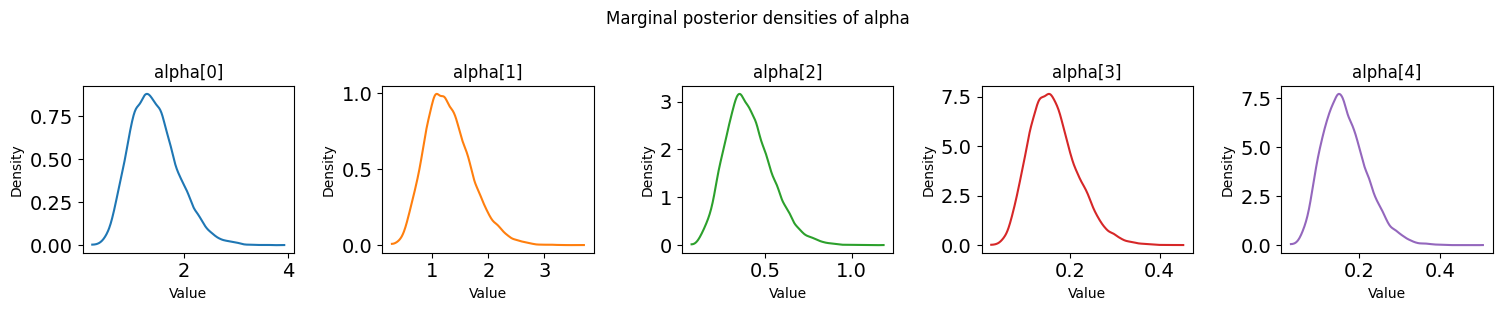

In [4]:
import matplotlib.pyplot as plt
import arviz as az

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3))
for i, ax in enumerate(axes):
    samples_i = trace.posterior["alpha"].sel(alpha_dim_0=i).values.flatten()
    az.plot_kde(samples_i, ax=ax, plot_kwargs={"color": f"C{i}"})
    ax.set_title(f"alpha[{i}]")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
fig.suptitle("Marginal posterior densities of alpha", y=1.02)
plt.tight_layout()
plt.show()

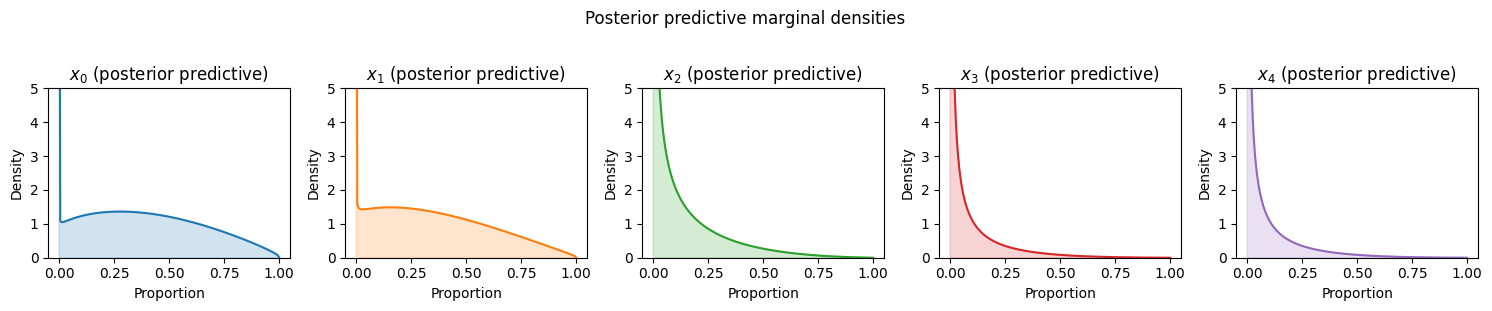

In [5]:
from scipy.stats import beta as beta_dist

# All posterior alpha samples: shape (S, K)
alpha_samples = trace.posterior["alpha"].values.reshape(-1, K)
alpha_mean = alpha_samples.mean(axis=0)

x = np.linspace(1e-6, 1 - 1e-6, 200)

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3))
for i, ax in enumerate(axes):
    # Posterior predictive: average Beta pdf over all MCMC samples
    pdf_avg = np.zeros_like(x)
    for s in range(len(alpha_samples)):
        a_i = alpha_samples[s, i]
        b_i = alpha_samples[s].sum() - a_i
        pdf_avg += beta_dist.pdf(x, a_i, b_i)
    pdf_avg /= len(alpha_samples)

    ax.plot(x, pdf_avg, color=f"C{i}")
    ax.fill_between(x, pdf_avg, alpha=0.2, color=f"C{i}")
    ax.set_title(f"$x_{i}$ (posterior predictive)")
    ax.set_xlabel("Proportion")
    ax.set_ylabel("Density")
    ax.set_ylim(0, 5)
fig.suptitle("Posterior predictive marginal densities", y=1.02)
plt.tight_layout()
plt.show()

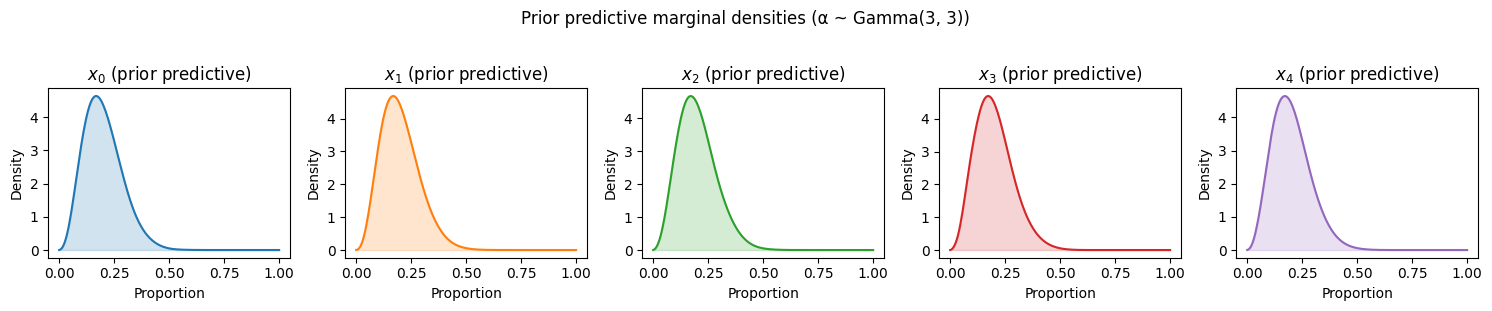

In [6]:
# Prior predictive: sample alpha_i ~ Gamma(1, 0.1) independently, then average Beta PDFs
from scipy.stats import gamma as gamma_dist

rng = np.random.default_rng(42)
n_prior_samples = 16000
alpha_prior_samples = gamma_dist.rvs(a=5, scale=5, size=(n_prior_samples, K), random_state=rng)

fig, axes = plt.subplots(1, K, figsize=(3 * K, 3))
for i, ax in enumerate(axes):
    pdf_avg = np.zeros_like(x)
    for s in range(n_prior_samples):
        a_i = alpha_prior_samples[s, i]
        b_i = alpha_prior_samples[s].sum() - a_i
        pdf_avg += beta_dist.pdf(x, a_i, b_i)
    pdf_avg /= n_prior_samples

    ax.plot(x, pdf_avg, color=f"C{i}")
    ax.fill_between(x, pdf_avg, alpha=0.2, color=f"C{i}")
    ax.set_title(f"$x_{i}$ (prior predictive)")
    ax.set_xlabel("Proportion")
    ax.set_ylabel("Density")
fig.suptitle("Prior predictive marginal densities (α ~ Gamma(3, 3))", y=1.02)
plt.tight_layout()
plt.show()

In [7]:
from scipy.stats import dirichlet
from scipy.special import logsumexp

# Posterior predictive log-likelihood: log (1/S) Σ_s Dir(x; α^(s))
def posterior_predictive_llh(samples_array, alpha_samples):
    S = len(alpha_samples)
    llhs = []
    for j in range(samples_array.shape[0]):
        log_liks = np.array([
            dirichlet.logpdf(samples_array[j], alpha_samples[s])
            for s in range(S)
        ])
        llhs.append(logsumexp(log_liks) - np.log(S))
    return np.array(llhs)

llh_train = posterior_predictive_llh(props, alpha_samples)

for i, llh in enumerate(llh_train):
    print(f"Sample {i}: LLH = {llh:.4f}")
print(f"\nMean LLH: {llh_train.mean():.4f}")

Sample 0: LLH = 21.3386
Sample 1: LLH = 20.8620
Sample 2: LLH = 28.3201
Sample 3: LLH = 20.8656

Mean LLH: 22.8466


In [8]:
different_samples = np.array([
    [0.2, 0.4, 0.1, 0., 0.3],
    [0.1, 0.4, 0.1, 0., 0.4],
])

In [9]:
diff_props = np.clip(different_samples, eps, None)
diff_props = diff_props / diff_props.sum(axis=1, keepdims=True)

llh_diff = posterior_predictive_llh(diff_props, alpha_samples)

for i, llh in enumerate(llh_diff):
    print(f"Sample {i}: LLH = {llh:.4f}")
print(f"\nMean LLH: {llh_diff.mean():.4f}")

Sample 0: LLH = 9.9633
Sample 1: LLH = 9.5146

Mean LLH: 9.7390


could have a scheme where we can compare LLH until the point we reach the lowest LLH of the real samples